# Data and preprocessing figures

Generates figures that illustrate selected waveform records and their preprocessing steps.


In [1]:
# ==========================================
# 1. IMPORTS AND PATHS
# ==========================================
import sys
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import windows as spwin
from obspy import read as obspy_read
from obspy.taup import TauPyModel
from obspy.signal.trigger import classic_sta_lta


def _find_repo_root(start: Path) -> Path:
    for p in (start, *start.parents):
        if (p / "data" / "raw").is_dir() and (p / "src").is_dir():
            return p
    return start


REPO_ROOT = _find_repo_root(Path.cwd().resolve())
sys.path.insert(0, str(REPO_ROOT / "src" / "preprocessing"))
import preprocessing_utils as pp  # noqa: E402

CATALOG_DIR = REPO_ROOT / "data" / "raw" / "catalog"
WAVEFORMS_DIR = REPO_ROOT / "data" / "raw" / "waveforms"
INTERIM_DIR = REPO_ROOT / "data" / "interim" / "preprocessing"
FIGURES_DIR = REPO_ROOT / "data" / "processed" / "images" / "preprocessing"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
print(f"Repo root:   {REPO_ROOT}")
print(f"Figures ->   {FIGURES_DIR}")

Repo root:   M:\Github\TFM_SeismicPhasePicker_ColombianAndes
Figures ->   M:\Github\TFM_SeismicPhasePicker_ColombianAndes\thesis\imagenes


In [2]:
# ==========================================
# 2. CONFIGURATION
# ==========================================
STATION = "ZAR"        # single station to illustrate
N_SCAN = 300           # windows scanned to find candidates (bounded on slow M:)
N_CANDIDATES = 5       # candidate records with a clear arrival to choose from
FIG_DATA_INDEX = 0     # which candidate (0..N_CANDIDATES-1) for the 4.2.2 figure
FIG_PREP_INDEX = 0     # which candidate for the 4.2.3 figure

# Manual arrival times for the illustration, in seconds from the window start.
# Set either value to None to omit that reference marker.
P_MANUAL_S = 26.875
S_MANUAL_S = 42.08

# Optional time-axis zoom in seconds.
# None shows the full window.
XLIM = None

# Figure style
RAW_COLOR = "0.25"        # raw waveform
PROC_COLOR = "crimson"    # preprocessed waveform
BASELINE_COLOR = "orange"  # removed baseline line (demean+detrend)
ZERO_LINE_COLOR = "k"     # zero reference line on the processed rows
P_COLOR = "k"      # P arrival marker
S_COLOR = "#1f77b4"      # S arrival marker
# Save vector PDF and PNG versions.
# Rasterize waveform traces at the configured DPI.
DPI = 1000
SAVE_FORMATS = ["pdf", "png"]
plt.rcParams["pdf.fonttype"] = 42   # embed TrueType fonts in the PDF
plt.rcParams["ps.fonttype"] = 42

sta_dir = WAVEFORMS_DIR / STATION
stations_df = pd.read_csv(CATALOG_DIR / "Stations_Required.csv")
STA_ELEV_KM = float(stations_df.loc[stations_df["Code"] == STATION, "Elevation"].iloc[0]) / 1000.0
_TAUP = TauPyModel(model="iasp91")


def save_fig(fig, name):
    for fmt in SAVE_FORMATS:
        out = FIGURES_DIR / f"{name}.{fmt}"
        fig.savefig(out, dpi=DPI, bbox_inches="tight")
        print(f"saved {out}")


def theoretical_ps_samples(station_dir, timestamp):
    """Approximate P and S arrival samples from the SAC header + iasp91.
    P is at sample THEORETICAL_P_SAMPLE by construction; S is P + (tS - tP)."""
    tr = obspy_read(str(station_dir / f"{STATION}.HHZ.{timestamp}.SAC"), format="SAC")[0]
    dist_deg = float(tr.stats.sac["dist"])
    evdp_km = float(tr.stats.sac["evdp"])
    p_sample = pp.THEORETICAL_P_SAMPLE
    s_sample = None
    try:
        arrs = _TAUP.get_travel_times(
            source_depth_in_km=evdp_km + STA_ELEV_KM,
            distance_in_degree=dist_deg, phase_list=["P", "S"],
        )
        t_p = next((a.time for a in arrs if a.name.upper().startswith("P")), None)
        t_s = next((a.time for a in arrs if a.name.upper().startswith("S")), None)
        if t_p is not None and t_s is not None:
            s = int(round((pp.TIME_BEFORE_P_S + (t_s - t_p)) * pp.SAMPLING_RATE_HZ))
            s_sample = s if 0 <= s < pp.NPTS else None
    except Exception as exc:
        print(f"taup error for {timestamp}: {exc}")
    return p_sample, s_sample


# STA/LTA arrival markers for this illustration
STA_P_S, LTA_P_S = 1.0, 10.0     # STA/LTA windows for P (seconds)
STA_S_S, LTA_S_S = 1.0, 12.0     # STA/LTA windows for S (seconds)
P_SEARCH_S = (22.0, 36.0)        # time window to look for P (seconds)
S_SEARCH_S = None                # (lo, hi) seconds for S; None -> around theoretical S
STALTA_THR = 3.0                 # onset threshold on the STA/LTA characteristic function


def _auto_onset(sig, sta_s, lta_s, lo_s, hi_s, thr=STALTA_THR):
    sr = pp.SAMPLING_RATE_HZ
    cft = classic_sta_lta(np.asarray(sig, dtype=float), int(sta_s * sr), int(lta_s * sr))
    lo, hi = int(lo_s * sr), int(hi_s * sr)
    seg = cft[lo:hi]
    if seg.size == 0:
        return None
    above = np.where(seg > thr)[0]
    return lo + (int(above[0]) if above.size else int(np.argmax(seg)))


def auto_ps_samples(station_dir, timestamp):
    """Detect P (on Z) and S (on horizontals) with STA/LTA near the theoretical
    times. Returns (p_sample, s_sample) or Nones."""
    arr = pp.load_window_array(station_dir, timestamp, preprocess=True)
    if arr is None:
        return None, None
    z = arr[0]
    horiz = np.sqrt(arr[1] ** 2 + arr[2] ** 2)
    p_sample = _auto_onset(z, STA_P_S, LTA_P_S, *P_SEARCH_S)
    if S_SEARCH_S is not None:
        s_lo, s_hi = S_SEARCH_S
    else:
        _, s_th = theoretical_ps_samples(station_dir, timestamp)
        if s_th is not None:
            s_c = s_th / pp.SAMPLING_RATE_HZ
            s_lo, s_hi = s_c - 8.0, s_c + 8.0
        else:
            p_c = (p_sample / pp.SAMPLING_RATE_HZ) if p_sample else pp.TIME_BEFORE_P_S
            s_lo, s_hi = p_c + 5.0, p_c + 45.0
    s_sample = _auto_onset(horiz, STA_S_S, LTA_S_S, s_lo, s_hi)
    return p_sample, s_sample


print(f"Station {STATION}  (elevation {STA_ELEV_KM * 1000:.0f} m)")

Station ZAR  (elevation 205 m)


## 3. Candidate records

Rank a sample of QC-passed windows by an amplitude-to-background proxy, then inspect candidates before choosing an illustrative trace.

In [3]:
def arrival_proxy(pre: np.ndarray) -> float:
    """Peak amplitude vs. RMS of the first 20 s (rough 'is there an arrival?')."""
    noise = pre[:, :2000]
    return float(np.max(np.abs(pre)) / (np.sqrt(np.mean(noise ** 2)) + 1e-12))


inv_path = INTERIM_DIR / f"window_inventory_{STATION}.csv"
if inv_path.exists():
    valid_ts = pd.read_csv(inv_path).query("status == 'ok'")["timestamp"].astype(str).tolist()
else:
    valid_ts = list(pp.group_station_windows(sta_dir).keys())

random.seed(0)
sample = valid_ts if len(valid_ts) <= N_SCAN else random.sample(valid_ts, N_SCAN)
rows = []
for ts in sample:
    pre = pp.load_window_array(sta_dir, ts, preprocess=True)
    if pre is not None:
        rows.append((ts, arrival_proxy(pre)))

ranked = pd.DataFrame(rows, columns=["timestamp", "arrival_proxy"]).sort_values(
    "arrival_proxy", ascending=False)
candidates = ranked["timestamp"].head(N_CANDIDATES).tolist()

info = []
for ts in candidates:
    p_s, s_s = theoretical_ps_samples(sta_dir, ts)
    sp_sec = (s_s - p_s) / pp.SAMPLING_RATE_HZ if s_s is not None else np.nan
    info.append({"timestamp": ts,
                 "arrival_proxy": float(ranked.set_index("timestamp").loc[ts, "arrival_proxy"]),
                 "S-P (s)": sp_sec})
candidates_df = pd.DataFrame(info)
print(f"Scanned {len(ranked)} windows of {STATION}. Top {N_CANDIDATES} candidates:\n")
print(candidates_df.to_string(index=True, float_format=lambda v: f"{v:,.2f}"))

Scanned 300 windows of ZAR. Top 5 candidates:

           timestamp  arrival_proxy  S-P (s)
0  2018.344.11.50.07       3,560.74    16.56
1  2018.255.05.48.58       3,212.68     6.49
2  2018.183.07.47.53         457.54    20.97
3  2018.157.21.54.16         356.58    18.57
4  2019.045.21.09.53         329.70    27.75


## 4. Three-component waveform

Select the record with `FIG_DATA_INDEX` and show the P and S markers used for this illustration.

[2018.344.11.50.07] manual vs calculated (STA/LTA):
  P: manual=26.875  calc=26.61  diff=-0.27 s
  S: manual=42.08  calc=42.31  diff=+0.23 s
saved M:\Github\TFM_SeismicPhasePicker_ColombianAndes\thesis\imagenes\RegistrosCrudos_ZAR_2018.344.11.50.07.pdf
saved M:\Github\TFM_SeismicPhasePicker_ColombianAndes\thesis\imagenes\RegistrosCrudos_ZAR_2018.344.11.50.07.png


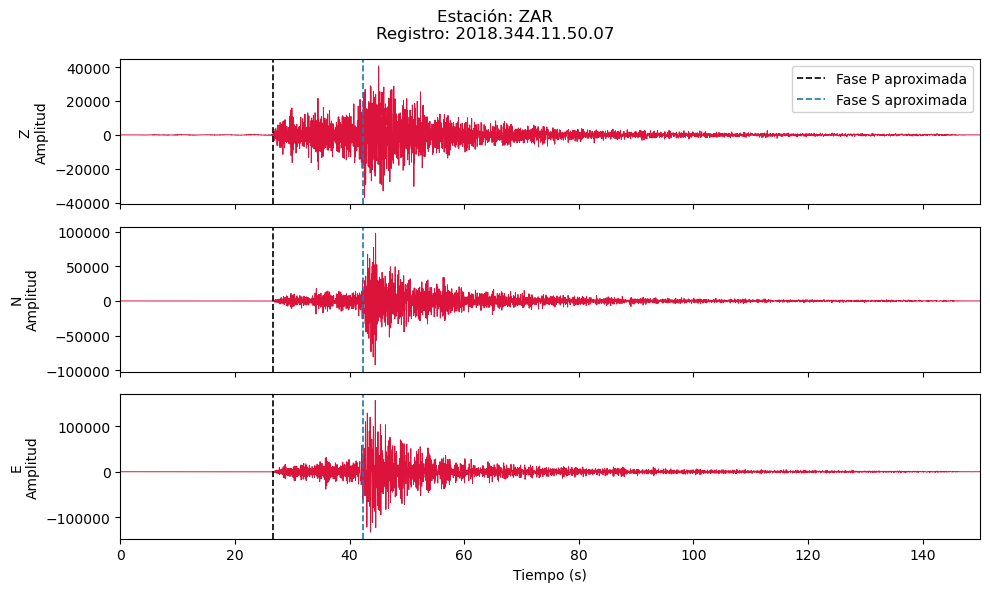

In [4]:
def figure_seismic_data(station_dir, timestamp, preprocess=True):
    arr = pp.load_window_array(station_dir, timestamp, preprocess=preprocess)
    if arr is None:
        print(f"{timestamp}: window did not pass QC.")
        return None
    # Estimate arrival markers with STA/LTA.
    p_auto, s_auto = auto_ps_samples(station_dir, timestamp)
    p_auto_s = p_auto / pp.SAMPLING_RATE_HZ if p_auto is not None else None
    s_auto_s = s_auto / pp.SAMPLING_RATE_HZ if s_auto is not None else None
    p_man = float(P_MANUAL_S) if P_MANUAL_S is not None else None
    s_man = float(S_MANUAL_S) if S_MANUAL_S is not None else None

    t = np.arange(pp.NPTS) / pp.SAMPLING_RATE_HZ
    color = PROC_COLOR if preprocess else RAW_COLOR

    fig, ax = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
    for i, comp in enumerate("ZNE"):
        ax[i].plot(t, arr[i], lw=0.7, color=color, rasterized=True)
        # calculated (STA/LTA) arrivals
        if p_auto_s is not None:
            ax[i].axvline(p_auto_s, color=P_COLOR, ls="--", lw=1.2,
                          label="Fase P aproximada" if i == 0 else None)
        if s_auto_s is not None:
            ax[i].axvline(s_auto_s, color=S_COLOR, ls="--", lw=1.2,
                          label="Fase S aproximada" if i == 0 else None)
        ax[i].set_ylabel(f"{comp}\nAmplitud")
        ax[i].margins(x=0)
    if XLIM is not None:
        ax[0].set_xlim(*XLIM)   # shared x-axis zoom to inspect the arrivals
    ax[0].legend(loc="upper right", framealpha=0.9)
    ax[-1].set_xlabel("Tiempo (s)")
    fig.suptitle(f"Estación: {STATION}\nRegistro: {timestamp}")
    plt.tight_layout()

    # Compare reference markers with STA/LTA estimates.
    def _diff(a, b):
        return f"{a - b:+.2f} s" if (a is not None and b is not None) else "n/a"
    print(f"[{timestamp}] manual vs calculated (STA/LTA):")
    print(f"  P: manual={p_man}  calc={None if p_auto_s is None else round(p_auto_s, 3)}  diff={_diff(p_auto_s, p_man)}")
    print(f"  S: manual={s_man}  calc={None if s_auto_s is None else round(s_auto_s, 3)}  diff={_diff(s_auto_s, s_man)}")
    return fig


ts_data = candidates[FIG_DATA_INDEX]
fig = figure_seismic_data(sta_dir, ts_data, preprocess=True)
if fig is not None:
    save_fig(fig, f"RegistrosCrudos_{STATION}_{ts_data}")
    plt.show()

## 5. Conditioning steps

Select the record with `FIG_PREP_INDEX` and compare the raw, demeaned, detrended, and tapered traces.

Preprocessing-figure record (clear arrival + strong baseline): 2019.286.03.49.47
saved M:\Github\TFM_SeismicPhasePicker_ColombianAndes\thesis\imagenes\RegistrosPreprocesados_ZAR_2019.286.03.49.47.pdf
saved M:\Github\TFM_SeismicPhasePicker_ColombianAndes\thesis\imagenes\RegistrosPreprocesados_ZAR_2019.286.03.49.47.png


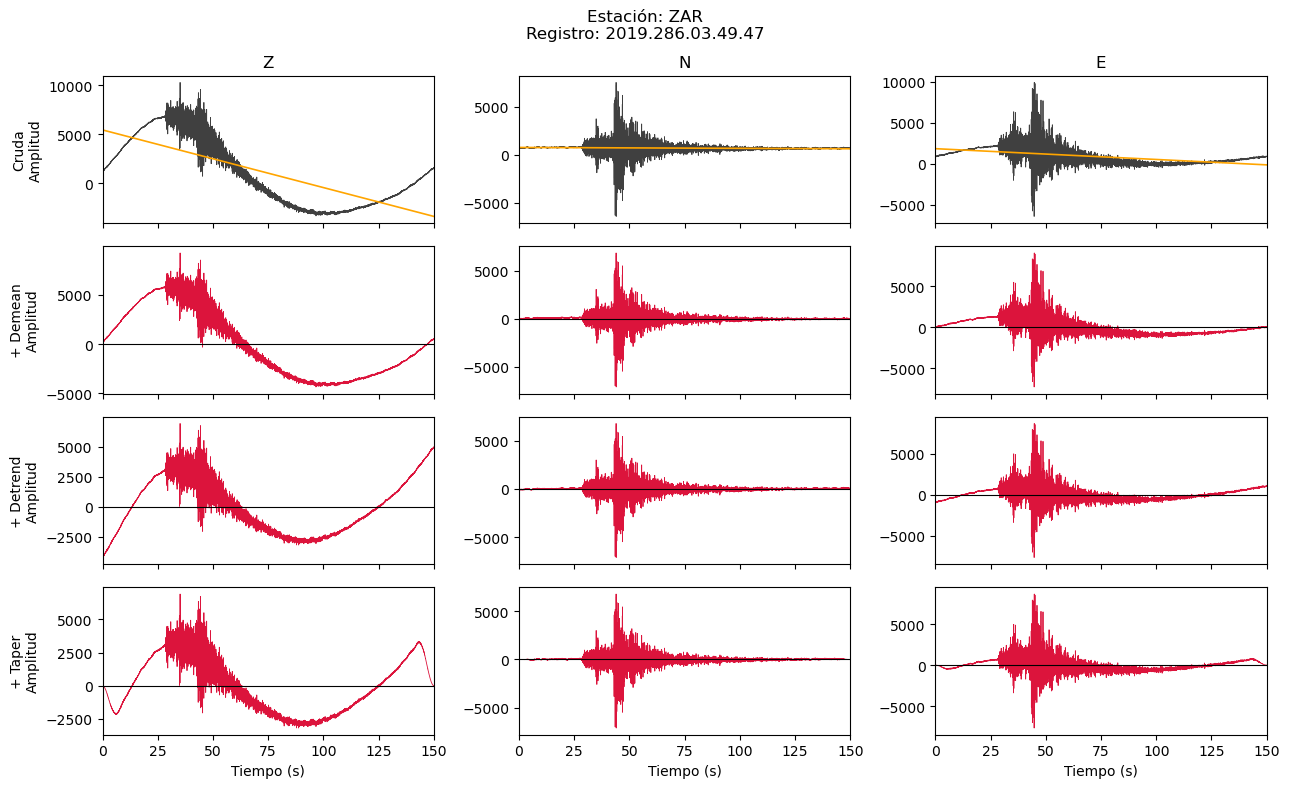

In [5]:
STAGE_LABELS = ["Cruda", "+ Demean", "+ Detrend", "+ Taper"]


def _stages(raw):
    """Reproduce the pipeline stage by stage (demean -> detrend -> taper)."""
    n = raw.shape[1]
    x = np.arange(n)
    demean = raw - raw.mean(axis=1, keepdims=True)
    detrend = np.empty_like(demean)
    for c in range(raw.shape[0]):
        detrend[c] = demean[c] - np.polyval(np.polyfit(x, demean[c], 1), x)
    taper = detrend * spwin.tukey(n, alpha=2 * pp.TAPER_MAX_PERCENTAGE)
    return [raw, demean, detrend, taper]


def figure_preprocessing_steps(station_dir, timestamp):
    raw = pp.load_window_array(station_dir, timestamp, preprocess=False)
    if raw is None:
        print(f"{timestamp}: window did not pass QC.")
        return None
    stages = _stages(raw)
    t = np.arange(pp.NPTS) / pp.SAMPLING_RATE_HZ
    x = np.arange(pp.NPTS)

    fig, ax = plt.subplots(len(stages), 3, figsize=(13, 8), sharex=True)
    for r, arr in enumerate(stages):
        for c, comp in enumerate("ZNE"):
            ax[r, c].plot(t, arr[c], lw=0.6, color=(RAW_COLOR if r == 0 else PROC_COLOR), rasterized=True)
            if r == 0:  # overlay the baseline that demean+detrend will remove
                slope, intercept = np.polyfit(x, arr[c], 1)
                ax[r, c].plot(t, slope * x + intercept, color=BASELINE_COLOR, lw=1.2)
                ax[r, c].set_title(comp)
            else:
                ax[r, c].axhline(0, color=ZERO_LINE_COLOR, lw=0.8)
            ax[r, c].margins(x=0)
        ax[r, 0].set_ylabel(f"{STAGE_LABELS[r]}\nAmplitud")
    for c in range(3):
        ax[-1, c].set_xlabel("Tiempo (s)")
    if XLIM is not None:
        ax[0, 0].set_xlim(*XLIM)   # shared x-axis zoom
    fig.suptitle(f"Estación: {STATION}\nRegistro: {timestamp}")
    plt.tight_layout()
    return fig


# Select a record with a clear arrival proxy and a strong baseline.
PREP_ARRIVAL_QUANTILE = 0.6   # keep the clearest ~40% by arrival, then strongest baseline


def _baseline_score(raw):
    n = raw.shape[1]
    x = np.arange(n)
    offset = float(np.max(np.abs(raw.mean(axis=1))))
    drift = max(abs(np.polyfit(x, raw[c], 1)[0]) * (n - 1) for c in range(raw.shape[0]))
    return offset + drift


random.seed(0)
_sample = valid_ts if len(valid_ts) <= N_SCAN else random.sample(valid_ts, N_SCAN)
_rows = []
for ts in _sample:
    raw = pp.load_window_array(sta_dir, ts, preprocess=False)
    pre = pp.load_window_array(sta_dir, ts, preprocess=True)
    if raw is None or pre is None:
        continue
    _rows.append((ts, arrival_proxy(pre), _baseline_score(raw)))

_df = pd.DataFrame(_rows, columns=["ts", "arrival", "baseline"]).set_index("ts")
_clear = _df[_df["arrival"] >= _df["arrival"].quantile(PREP_ARRIVAL_QUANTILE)]
ts_prep = _clear["baseline"].idxmax()
print(f"Preprocessing-figure record (clear arrival + strong baseline): {ts_prep}")
fig = figure_preprocessing_steps(sta_dir, ts_prep)
if fig is not None:
    save_fig(fig, f"RegistrosPreprocesados_{STATION}_{ts_prep}")
    plt.show()